<hr>
<div>
<h2>Initialize Modeling Environment</h2>
<p>Initializes the shared imports, plotting style, and data access used throughout section 02. Tables load through <code>retention.data.load()</code>, which refuses answer-key tables; features come from <code>retention.features</code> and the uplift learners from <code>retention.uplift</code>. Section 01's churn scores are read from <code>outputs/</code>.</p>
</div>

In [1]:
# Standard Library
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import KFold
from sklift.metrics import qini_auc_score, qini_curve
from IPython.display import display

sys.path.insert(0, 'src')
from retention import data, features as F, uplift as U

warnings.filterwarnings('ignore', category = FutureWarning)
pd.set_option('display.width', 140)
pd.set_option('display.max_columns', 40)

In [2]:
# Plotting Theme and Color Palette
SURFACE = '#ffffff'
INK = '#0b0b0b'
MUTED = '#898781'
GRID = '#e1e0d9'
BASELINE = '#c3c2b7'
ACCENT = '#2a78d6'
ACCENT2 = '#eb6834'
TEAL = '#1baf7a'
YELLOW = '#eda100'
PINK = '#e87ba4'

plt.rcParams.update({
    'figure.dpi': 110,
    'figure.facecolor': SURFACE,
    'axes.facecolor': SURFACE,
    'savefig.facecolor': SURFACE,
    'axes.edgecolor': BASELINE,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'grid.color': GRID,
    'grid.linewidth': 0.8,
    'grid.linestyle': '-',
    'axes.axisbelow': True,
    'font.size': 9,
    'text.color': INK,
    'axes.labelcolor': INK,
    'xtick.color': MUTED,
    'ytick.color': MUTED,
})

In [3]:
# Output Helpers & Constants
OUTPUTS = Path('outputs')
SEED = 20260921
CAMPAIGN_1_MONTH = 13
CAMPAIGN_2_MONTH = 19
N_MONTHS = 24
OFFERS = ['discount', 'device', 'data']
OFFER_LABELS = {'discount': 'Discount', 'device': 'Device credit', 'data': 'Data upgrade'}
LEARNER_COLORS = {'T-learner': PINK, 'X-learner': YELLOW, 'DR-learner': ACCENT2, 'Flag DR-learner': ACCENT, 'Risk-scaled logit': TEAL, 'Churn risk': MUTED}


def load_output(name):
    return pd.read_parquet(OUTPUTS / f'{name}.parquet')


def save_output(df, name):

    path = OUTPUTS / f'{name}.parquet'
    df.to_parquet(path, index = False)

    return path


def left_within(panel, month, months = 3):
    """Accounts that left in the `months` after `month`."""

    return set(panel.loc[panel['month'].between(month + 1, month + months) & panel['churned'], 'account_id'])

<hr style="border: none; border-top: 2px solid #4A4A4A;">
<div>
<h1>02 · Offer Effect</h1>
<p><strong>Purpose:</strong> Estimates, for each customer and each offer, how much the offer would lower the chance of leaving within 90 days: the uplift. Section 01 found who is likely to leave; this section finds whom an offer would actually keep.</p>
<p><strong>Architecture:</strong> Uplift can't be observed for any one customer, who either got an offer or didn't. The randomized campaign in month 13 makes it estimable: offered and control customers differ only by chance, so the difference in their churn, within any group of similar customers, is the offer's effect on that group.</p>
<table style="width: 100%; border-collapse: collapse;">
<thead><tr><th style="text-align: left;">Stage</th><th style="text-align: left;">Method</th><th style="text-align: left;">Why</th></tr></thead>
<tbody>
<tr><td style="text-align: left; vertical-align: top;">1 · Campaign 1 data</td><td style="text-align: left; vertical-align: top;">Month-13 features, 90-day outcomes, average effects</td><td style="text-align: left; vertical-align: top;">What the test measured on average</td></tr>
<tr><td style="text-align: left; vertical-align: top;">2 · Uplift learners</td><td style="text-align: left; vertical-align: top;">Five learners, from gradient-boosted to a risk-scaled logit, cross-predicted</td><td style="text-align: left; vertical-align: top;">Who responds, estimated five ways</td></tr>
<tr><td style="text-align: left; vertical-align: top;">3 · Observed outcomes</td><td style="text-align: left; vertical-align: top;">Qini curves</td><td style="text-align: left; vertical-align: top;">How an analyst would judge the models</td></tr>
<tr><td style="text-align: left; vertical-align: top;">4 · Answer key</td><td style="text-align: left; vertical-align: top;">True uplift captured by each model's top picks</td><td style="text-align: left; vertical-align: top;">How good they really are</td></tr>
<tr><td style="text-align: left; vertical-align: top;">5 · What the situations say</td><td style="text-align: left; vertical-align: top;">Odds multipliers from the risk-scaled logit</td><td style="text-align: left; vertical-align: top;">Which situations drive each offer's effect</td></tr>
<tr><td style="text-align: left; vertical-align: top;">6 · Campaign 2</td><td style="text-align: left; vertical-align: top;">Naive estimate against the true effect</td><td style="text-align: left; vertical-align: top;">Why the randomized test matters</td></tr>
<tr><td style="text-align: left; vertical-align: top;">7 · Acceptance</td><td style="text-align: left; vertical-align: top;">Who takes each offer</td><td style="text-align: left; vertical-align: top;">Expected cost for the optimizer</td></tr>
<tr><td style="text-align: left; vertical-align: top;">8 · Tonight's batch</td><td style="text-align: left; vertical-align: top;">Score month 24; save for the optimizer</td><td style="text-align: left; vertical-align: top;">Handoff to section 04</td></tr>
</tbody>
</table>
</div>

<hr>
<div>
<h2>1 · Campaign 1 Data</h2>
<p><strong>Purpose:</strong> Assembles the randomized test: each of the 40,000 accounts' features at the time of the offer, its arm, whether it accepted, and whether it left within 90 days, then measures each offer's average effect.</p>
<p><strong>Design Notes:</strong></p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Features.</strong> The month-13 row of <code>retention.features</code>, the situation flags from <code>retention.uplift</code>, and section 01's 90-day churn risk, scored by a model fitted on months 1–12 only.</li>
<li style="margin-bottom: 0.7em;"><strong>Outcome.</strong> Left in months 14–16, the 90 days after the offer. Offered customers are compared with control whether or not they accepted (intention to treat): the carrier chooses whom to offer, not who accepts.</li>
<li style="margin-bottom: 0.7em;"><strong>Average Effect.</strong> Control churn minus offer churn, with a 95% interval.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>The discount works on average; the others are marginal.</strong> The discount lowered 90-day churn from 4.55% to 3.61%, 0.94 points (95% interval 0.42 to 1.46). The device credit lowered it 0.58 points, with an interval that barely excludes zero; the data upgrade's 0.08 points is indistinguishable from nothing.</li>
<li style="margin-bottom: 0.7em;"><strong>About half of discount offers are accepted.</strong> 49% for the discount, 40% for the device credit, and 31% for the data upgrade, which only suits the 15 GB plan.</li>
</ol>
</div>

In [4]:
# Assemble Campaign 1
panel = data.load('monthly_panel')
accounts = data.load('accounts')
contacts = data.load('care_contacts')
campaigns = data.load('campaigns')
account_months = F.build_features(panel, accounts, contacts)


def model_inputs(rows, risk):
    X = F.as_model_frame(rows).reset_index(drop = True)
    X = pd.concat([X, U.situation_flags(rows).reset_index(drop = True)], axis = 1)
    X['p_churn_90'] = rows[['account_id']].merge(risk, on = 'account_id', how = 'left')['p_churn_90'].to_numpy()
    return X


campaign_1 = (account_months[account_months['month'] == CAMPAIGN_1_MONTH]
              .merge(campaigns.loc[campaigns['campaign'] == 'campaign_1', ['account_id', 'arm', 'accepted']], on = 'account_id')
              .reset_index(drop = True))
campaign_1['left_90'] = campaign_1['account_id'].isin(left_within(panel, CAMPAIGN_1_MONTH)).astype(int)
X_campaign_1 = model_inputs(campaign_1, load_output('campaign_1_churn_scores'))

by_arm = campaign_1.groupby('arm').agg(accounts = ('account_id', 'size'), accepted = ('accepted', 'mean'), churn_90 = ('left_90', 'mean')).reindex(['control'] + OFFERS)
p0, n0 = by_arm.loc['control', ['churn_90', 'accounts']]
se = np.sqrt(p0 * (1 - p0) / n0 + by_arm['churn_90'] * (1 - by_arm['churn_90']) / by_arm['accounts'])
by_arm['effect, points'] = (p0 - by_arm['churn_90']) * 100
by_arm['95% interval'] = [f'{(e - 1.96 * s * 100):+.2f} to {(e + 1.96 * s * 100):+.2f}' for e, s in zip(by_arm['effect, points'], se)]
by_arm.loc['control', ['effect, points', '95% interval']] = [np.nan, '–']
display(by_arm.style.format({'accounts': '{:,.0f}', 'accepted': '{:.0%}', 'churn_90': '{:.2%}', 'effect, points': '{:+.2f}'}, na_rep = '–'))

,accounts,accepted,churn_90,"effect, points",95% interval
arm,,,,,
control,"16,119",0%,4.55%,–,–
discount,"7,958",49%,3.61%,+0.94,+0.42 to +1.46
device,"7,779",40%,3.97%,+0.58,+0.03 to +1.12
data,"8,144",31%,4.47%,+0.08,-0.47 to +0.63


<hr>
<div>
<h2>2 · Uplift Learners</h2>
<p><strong>Purpose:</strong> Estimates each customer's uplift for each offer five ways, from most flexible to most constrained, so the comparison shows how much structure a test of this size can support.</p>
<p><strong>Design Notes:</strong></p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Learners.</strong>
<table style="width: 100%; border-collapse: collapse;">
<thead><tr><th style="text-align: left;">Learner</th><th style="text-align: left;">How it estimates uplift</th></tr></thead>
<tbody>
<tr><td style="text-align: left; vertical-align: top;">T-learner</td><td style="text-align: left; vertical-align: top;">Two churn models, one per arm; uplift is the difference of their predictions</td></tr>
<tr><td style="text-align: left; vertical-align: top;">X-learner</td><td style="text-align: left; vertical-align: top;">Imputes each customer's effect from the other arm's churn model, then models those effects</td></tr>
<tr><td style="text-align: left; vertical-align: top;">DR-learner</td><td style="text-align: left; vertical-align: top;">Models a doubly robust pseudo-outcome with gradient-boosted trees</td></tr>
<tr><td style="text-align: left; vertical-align: top;">Flag DR-learner</td><td style="text-align: left; vertical-align: top;">The same pseudo-outcome, modeled by a ridge regression on 16 situation flags</td></tr>
<tr><td style="text-align: left; vertical-align: top;">Risk-scaled logit</td><td style="text-align: left; vertical-align: top;">A logistic regression of churn on section 01's risk, the flags, the offer, and offer-by-flag terms. An offer scales a customer's odds of leaving, so uplift grows with risk as well as with the situation</td></tr>
</tbody>
</table></li>
<li style="margin-bottom: 0.7em;"><strong>Situation Flags.</strong> Price pressure (a bill increase over 5% or a competitor promotion index over 0.4 in 3 months); each reason code in the past 6 months; phone within 3 months of payoff or paid off; phone 30+ months old; 15 GB plan, and capped on it; 3+ years' tenure; no contacts in 6 months; and four pairings: price pressure with a billing contact, near payoff with a device contact, near payoff with an old phone, long tenure with no contacts.</li>
<li style="margin-bottom: 0.7em;"><strong>Each Offer Separately.</strong> Each offer arm is paired with the shared control arm: 8,000 offered and 16,000 control accounts.</li>
<li style="margin-bottom: 0.7em;"><strong>Cross-Prediction.</strong> 5 folds: every account's uplift comes from models that never saw it, so the evaluations in sections 3 and 4 are out of sample.</li>
<li style="margin-bottom: 0.7em;"><strong>Benchmark.</strong> Ranking by section 01's churn risk, the common practice this study tests.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>The learners agree on the average.</strong> Every learner's mean uplift is within about 0.15 points of the measured average effect. Where they differ is who they rank at the top, which is what matters for targeting.</li>
</ol>
</div>

In [5]:
# Cross-Predict Uplift
predictions = {}
pairs = {}
for offer in OFFERS:
    in_pair = campaign_1['arm'].isin(['control', offer]).to_numpy()
    X = X_campaign_1[in_pair].reset_index(drop = True)
    t = (campaign_1.loc[in_pair, 'arm'] == offer).astype(int).to_numpy()
    y = campaign_1.loc[in_pair, 'left_90'].to_numpy()
    pairs[offer] = (campaign_1.loc[in_pair, 'account_id'].to_numpy(), X, t, y)
    predictions[offer] = {name: U.cross_predict(learner, X, t, y, seed = SEED) for name, learner in U.LEARNERS.items()}
    predictions[offer]['Churn risk'] = X['p_churn_90'].to_numpy()
    print(f"{OFFER_LABELS[offer]}: {t.sum():,} offered · {(1 - t).sum():,} control · "
          + ' · '.join(f'{n} mean {p.mean() * 100:+.2f}' for n, p in predictions[offer].items() if n != 'Churn risk'))

Discount: 7,958 offered · 16,119 control · T-learner mean +1.08 · X-learner mean +0.94 · DR-learner mean +0.93 · Flag DR-learner mean +0.93 · Risk-scaled logit mean +0.93


Device credit: 7,779 offered · 16,119 control · T-learner mean +0.74 · X-learner mean +0.61 · DR-learner mean +0.63 · Flag DR-learner mean +0.63 · Risk-scaled logit mean +0.61


Data upgrade: 8,144 offered · 16,119 control · T-learner mean +0.23 · X-learner mean +0.13 · DR-learner mean +0.08 · Flag DR-learner mean +0.09 · Risk-scaled logit mean +0.13


<hr>
<div>
<h2>3 · Observed Outcomes</h2>
<p><strong>Purpose:</strong> Judges the learners the way an analyst without an answer key would: by how many more customers stay when offers go to the model's top picks rather than at random, measured on the test's observed outcomes.</p>
<p><strong>Design Notes:</strong></p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Qini Curve.</strong> Customers sorted by predicted uplift; at each cut-off, the extra customers retained among the offered, compared with control customers of the same rank, scaled to the offered group's size. The area between the curve and the random line (Qini AUC) summarizes it; higher is better, and zero means no better than random.</li>
<li style="margin-bottom: 0.7em;"><strong>Noise.</strong> About 4% of accounts leave within 90 days, so each point on the curve rests on a few hundred departures. The curves are an honest but noisy read; section 4 checks them against the truth.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Observed outcomes can't separate the models.</strong> Every Qini AUC is within 0.005 of zero, and several are negative. The curves wander around the random line.</li>
<li style="margin-bottom: 0.7em;"><strong>They can mislead.</strong> The risk-scaled logit's discount curve runs below random, yet section 4 shows its top fifth holds 1.7 times the average true benefit. At a 4% outcome rate and 24,000 accounts a pair, a test this size can train an uplift model but can't grade one reliably. The answer key is what makes the comparison possible here; in practice, a follow-up test aimed at the model's top picks would be the check.</li>
</ol>
</div>

,discount,device,data
T-learner,-0.0014,-0.0036,-0.0045
X-learner,+0.0007,-0.0039,-0.0046
DR-learner,+0.0006,-0.0039,-0.0046
Flag DR-learner,-0.0037,-0.0039,-0.0009
Risk-scaled logit,-0.0043,-0.0042,+0.0007
Churn risk,-0.0011,-0.0006,+0.0002


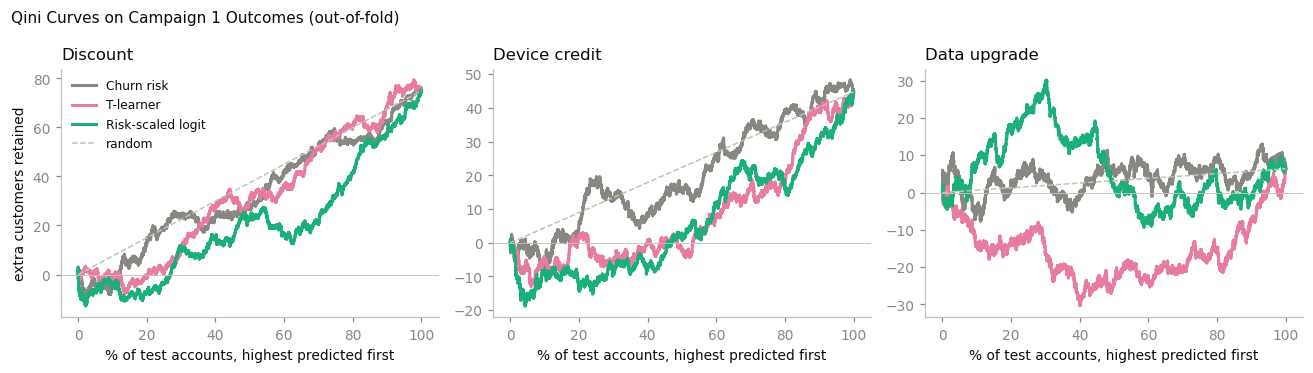

In [6]:
# Plot: Qini Curves on Observed Outcomes
qini_scores = pd.DataFrame({offer: {name: qini_auc_score(1 - pairs[offer][3], p, pairs[offer][2])
                                    for name, p in predictions[offer].items()} for offer in OFFERS})
display(qini_scores.style.format('{:+.4f}').set_caption('Qini AUC on observed outcomes (retained = 1; 0 = random)'))

fig, axes = plt.subplots(1, 3, figsize = (12, 3.4))
for ax, offer in zip(axes, OFFERS):
    ids, X, t, y = pairs[offer]
    for name in ['Churn risk', 'T-learner', 'Risk-scaled logit']:
        x_curve, y_curve = qini_curve(1 - y, predictions[offer][name], t)
        ax.plot(x_curve / len(y) * 100, y_curve, color = LEARNER_COLORS[name], linewidth = 2, label = name)
    ax.plot([0, 100], [0, y_curve[-1]], color = BASELINE, linewidth = 1, linestyle = '--', label = 'random')
    ax.axhline(0, color = BASELINE, linewidth = 0.6)
    ax.set_title(OFFER_LABELS[offer], loc = 'left')
    ax.set_xlabel('% of test accounts, highest predicted first')
axes[0].set_ylabel('extra customers retained')
axes[0].legend(frameon = False, fontsize = 8, loc = 'upper left')
fig.suptitle('Qini Curves on Campaign 1 Outcomes (out-of-fold)', fontsize = 10, x = 0.01, ha = 'left')
plt.tight_layout()
plt.show()

<hr>
<div>
<h2>4 · Answer Key</h2>
<p><strong>Purpose:</strong> Scores the same out-of-fold predictions against each account's true uplift, from the answer key: how much of the available benefit each model's top picks actually hold.</p>
<p><strong>Design Notes:</strong></p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Top-Fifth Capture.</strong> The average true uplift of the 20% of accounts each model ranks highest, divided by the average for all accounts. 1× is random; the true uplift itself, as a ranking, sets the ceiling.</li>
<li style="margin-bottom: 0.7em;"><strong>Rank Correlation.</strong> Spearman correlation between predicted and true uplift over all accounts.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Constrained models win.</strong> The flag DR-learner and the risk-scaled logit put 1.7 to 1.9 times the average true benefit in their top fifth for the discount and data upgrade. The gradient-boosted learners manage 1.2 to 1.3 times: with a rare outcome, flexible models fit the noise.</li>
<li style="margin-bottom: 0.7em;"><strong>The risk-scaled logit is the most balanced.</strong> It's the only learner that beats plain churn risk on all three offers: 1.72, 1.35, and 1.93 times, against 1.13, 1.27, and 1.13 times for risk.</li>
<li style="margin-bottom: 0.7em;"><strong>A large gap remains.</strong> The true uplift itself would put about 4 times the average in the top fifth. Most of what's missing depends on each customer's hidden reason for leaving, which the rep's codes reveal only partly; section 03 tests whether the care notes reveal more.</li>
</ol>
</div>

In [7]:
# Score Uplift against the Answer Key
truth_campaigns = data.load_answer_key('truth_campaign_outcomes')
truth_1 = truth_campaigns[truth_campaigns['campaign'] == 'campaign_1'].set_index('account_id')

capture, correlation = {}, {}
for offer in OFFERS:
    ids = pairs[offer][0]
    true = (truth_1['p_churn_90_control'] - truth_1[f'p_churn_90_{offer}']).loc[ids].to_numpy()
    top = len(true) // 5
    capture[offer] = {name: true[np.argsort(-p)[:top]].mean() / true.mean() for name, p in predictions[offer].items()}
    capture[offer]['Ceiling (true uplift)'] = np.sort(true)[::-1][:top].mean() / true.mean()
    correlation[offer] = {name: pd.Series(p).rank().corr(pd.Series(true).rank()) for name, p in predictions[offer].items()}
capture = pd.DataFrame(capture)
correlation = pd.DataFrame(correlation)
display(capture.style.format('{:.2f}×').set_caption('True uplift of each model\'s top fifth, relative to the average'))
display(correlation.style.format('{:+.2f}').set_caption('Rank correlation with true uplift'))

,discount,device,data
T-learner,1.21×,1.11×,1.29×
X-learner,1.29×,1.17×,1.34×
DR-learner,1.32×,1.11×,1.24×
Flag DR-learner,1.82×,0.92×,1.85×
Risk-scaled logit,1.72×,1.35×,1.93×
Churn risk,1.13×,1.27×,1.13×
Ceiling (true uplift),4.09×,4.43×,4.41×


,discount,device,data
T-learner,+0.07,+0.02,+0.02
X-learner,+0.07,+0.01,+0.04
DR-learner,+0.08,-0.00,+0.03
Flag DR-learner,+0.25,-0.06,+0.08
Risk-scaled logit,+0.25,-0.02,+0.09
Churn risk,+0.09,+0.15,+0.11


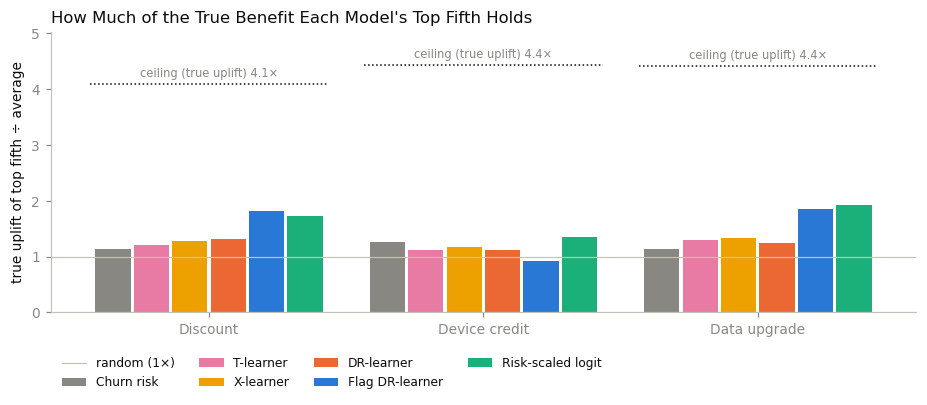

In [8]:
# Plot: Top-Fifth Capture by Learner
order = ['Churn risk', 'T-learner', 'X-learner', 'DR-learner', 'Flag DR-learner', 'Risk-scaled logit']
fig, ax = plt.subplots(figsize = (8.5, 3.8))
width = 0.14
for i, name in enumerate(order):
    x = np.arange(len(OFFERS)) + (i - 2.5) * width
    values = capture.loc[name, OFFERS].to_numpy()
    ax.bar(x, values, width = width * 0.92, color = LEARNER_COLORS[name], label = name)
for j, offer in enumerate(OFFERS):
    ceiling = capture.loc['Ceiling (true uplift)', offer]
    ax.hlines(ceiling, j - 3.1 * width, j + 3.1 * width, color = INK, linewidth = 1, linestyle = ':')
    ax.text(j, ceiling + 0.08, f'ceiling (true uplift) {ceiling:.1f}×', ha = 'center', va = 'bottom', fontsize = 7.5, color = MUTED)
ax.axhline(1, color = BASELINE, linewidth = 0.8, label = 'random (1×)')
ax.set_ylim(0, capture.loc['Ceiling (true uplift)'].max() + 0.6)
ax.set_xticks(range(len(OFFERS)))
ax.set_xticklabels([OFFER_LABELS[o] for o in OFFERS])
ax.set_ylabel('true uplift of top fifth ÷ average')
ax.set_title('How Much of the True Benefit Each Model\'s Top Fifth Holds', loc = 'left')
ax.legend(frameon = False, fontsize = 8, ncol = 4, loc = 'upper left', bbox_to_anchor = (0, -0.12))
plt.tight_layout()
plt.show()

<hr>
<div>
<h2>5 · What the Situations Say</h2>
<p><strong>Purpose:</strong> Fits the risk-scaled logit on the whole test for each offer and reads how the offer changes the odds of leaving, overall and in each situation.</p>
<p><strong>Design Notes:</strong></p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Reading the Multipliers.</strong> "Offer" is the multiplier on the odds of leaving for a customer with none of the flags; each flag's multiplier applies on top when that situation is present. Below 1× the offer works better in that situation; above 1×, worse. The four pairings apply on top of their parts.</li>
<li style="margin-bottom: 0.7em;"><strong>Shrinkage.</strong> The regression is regularized, so multipliers near 1× are best read as "no clear difference".</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>The discount works where price is the problem.</strong> Under price pressure with a recent billing call, the discount roughly halves the odds of leaving (0.93 × 0.73 × 1.09 × 0.68 ≈ 0.50); without those, it barely changes them.</li>
<li style="margin-bottom: 0.7em;"><strong>It does harm for customers who are moving.</strong> A recent account-change contact, the code reps use for moves, makes the discount's multiplier 1.40 times worse: the offer can't keep them, and costs money.</li>
<li style="margin-bottom: 0.7em;"><strong>The device credit's pattern is faint.</strong> A recent device contact helps (0.88×), but the other device-related flags are near 1×. The effect is real but concentrated in a small group (near payoff with a device call), too small in this test to estimate precisely.</li>
</ol>
</div>

In [9]:
# Fit Risk-Scaled Logit on the Whole Test
uplift_models = {offer: U.RiskScaledLogit().fit(pairs[offer][1], pairs[offer][2], pairs[offer][3]) for offer in OFFERS}
multipliers = pd.DataFrame({OFFER_LABELS[offer]: model.odds_multipliers() for offer, model in uplift_models.items()})
display(multipliers.style.format('{:.2f}×').background_gradient(cmap = 'RdBu_r', vmin = 0.3, vmax = 1.7, axis = None)
        .set_caption('Multiplier on the odds of leaving (below 1× = the offer works better)'))

,Discount,Device credit,Data upgrade
offer,0.93×,0.84×,0.98×
price_pressure,0.73×,1.06×,1.09×
billing_6m,1.09×,1.00×,1.06×
service_6m,1.07×,0.99×,0.95×
device_6m,1.01×,0.88×,1.00×
network_6m,1.21×,0.87×,0.69×
account_6m,1.40×,0.88×,0.89×
near_payoff,1.07×,0.97×,1.13×
old_device,1.00×,1.01×,0.97×
plan_15gb,0.94×,1.19×,0.81×


<hr>
<div>
<h2>6 · Why the Randomized Test Matters</h2>
<p><strong>Purpose:</strong> Shows what campaign 2, the month-19 campaign targeted at the top of a rep's at-risk list, would have said about the discount if analyzed the obvious way, and compares it with the discount's true effect on those customers.</p>
<p><strong>Design Notes:</strong></p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Naive Estimate.</strong> 90-day churn of contactable accounts that weren't targeted, minus that of the discount's recipients. The recipients were chosen because they looked at risk, so they would have left more often anyway.</li>
<li style="margin-bottom: 0.7em;"><strong>True Effect.</strong> The answer key's average uplift for the recipients.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>The naive estimate understates the discount by more than half.</strong> It says the discount cut 90-day churn by 0.39 points; its true effect on those customers was 0.89 points. The recipients would have left more often than untargeted accounts without the offer (3.64% against 3.39%), and a simple comparison charges that to the offer.</li>
<li style="margin-bottom: 0.7em;"><strong>That's why the uplift models train only on the randomized test.</strong> A targeted campaign mixes the offer's effect with the reasons customers were chosen.</li>
</ol>
</div>

In [10]:
# Compare Campaign 2's Naive Estimate with the Truth
at_19 = account_months[account_months['month'] == CAMPAIGN_2_MONTH].merge(accounts[['account_id', 'do_not_contact']], on = 'account_id')
at_19 = at_19[~at_19['do_not_contact']]
campaign_2 = campaigns[campaigns['campaign'] == 'campaign_2']
left_2 = left_within(panel, CAMPAIGN_2_MONTH)
recipients = campaign_2.loc[campaign_2['arm'] == 'discount', 'account_id']
treated = at_19['account_id'].isin(recipients)
untargeted = ~at_19['account_id'].isin(campaign_2['account_id'])
churn_2 = at_19['account_id'].isin(left_2)

truth_2 = truth_campaigns[(truth_campaigns['campaign'] == 'campaign_2') & truth_campaigns['account_id'].isin(recipients)]
comparison = pd.DataFrame({
    '90-day churn, recipients': [churn_2[treated].mean()],
    '90-day churn, not targeted': [churn_2[untargeted].mean()],
    'naive effect, points': [(churn_2[untargeted].mean() - churn_2[treated].mean()) * 100],
    'true effect on recipients, points': [(truth_2['p_churn_90_control'] - truth_2['p_churn_90_discount']).mean() * 100],
    'recipients\' churn without the offer': [truth_2['p_churn_90_control'].mean()],
}, index = ['Campaign 2 discount'])
display(comparison.style.format({c: '{:.2%}' for c in comparison.columns if 'churn' in c} | {c: '{:+.2f}' for c in comparison.columns if 'points' in c}))

,"90-day churn, recipients","90-day churn, not targeted","naive effect, points","true effect on recipients, points",recipients' churn without the offer
Campaign 2 discount,3.00%,3.39%,+0.39,+0.89,3.64%


<hr>
<div>
<h2>7 · Acceptance</h2>
<p><strong>Purpose:</strong> Models who accepts each offer when it's made. An offer costs the carrier only if it's accepted, so the optimizer's expected cost per customer is the offer's cost times this probability.</p>
<p><strong>Design Notes:</strong></p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Model.</strong> LightGBM classifier on the offered arm of each offer (8,000 accounts), with the same inputs as the uplift learners. Acceptance is common (around 40%), so the default settings are stable.</li>
<li style="margin-bottom: 0.7em;"><strong>Evaluation.</strong> Out-of-fold AUC against who accepted, and calibration against each account's true acceptance probability from the answer key.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Acceptance is only partly predictable.</strong> AUC 0.64 for the discount, 0.58 for the device credit, and 0.55 for the data upgrade. Acceptance depends mostly on the hidden reason and on how set a customer is on leaving.</li>
<li style="margin-bottom: 0.7em;"><strong>The level is right, which is what the budget needs.</strong> Tonight's average predicted acceptance is within a point of the truth for every offer (section 8), so expected costs will be accurate in total even where individual predictions aren't.</li>
</ol>
</div>

In [11]:
# Model Acceptance
ACCEPT_SETTINGS = dict(n_estimators = 300, learning_rate = 0.03, num_leaves = 15, min_child_samples = 100,
                       subsample = 0.8, subsample_freq = 1, colsample_bytree = 0.8, random_state = SEED, verbose = -1)
acceptance_models, acceptance_scores = {}, {}
for offer in OFFERS:
    offered = (campaign_1['arm'] == offer).to_numpy()
    X, accepted = X_campaign_1[offered].reset_index(drop = True), campaign_1.loc[offered, 'accepted'].astype(int).to_numpy()
    out_of_fold = np.zeros(len(accepted))
    for train, held in KFold(5, shuffle = True, random_state = SEED).split(X):
        out_of_fold[held] = lgb.LGBMClassifier(**ACCEPT_SETTINGS).fit(X.iloc[train], accepted[train]).predict_proba(X.iloc[held])[:, 1]
    true_accept = truth_1.loc[campaign_1.loc[offered, 'account_id'], f'accept_{offer}'].to_numpy()
    acceptance_scores[OFFER_LABELS[offer]] = {
        'accepted': accepted.mean(), 'AUC': roc_auc_score(accepted, out_of_fold),
        'correlation with true probability': np.corrcoef(out_of_fold, true_accept)[0, 1],
        'mean absolute error': np.abs(out_of_fold - true_accept).mean()}
    acceptance_models[offer] = lgb.LGBMClassifier(**ACCEPT_SETTINGS).fit(X, accepted)
display(pd.DataFrame(acceptance_scores).T.style.format({'accepted': '{:.0%}', 'AUC': '{:.3f}', 'correlation with true probability': '{:.2f}', 'mean absolute error': '{:.3f}'}))

,accepted,AUC,correlation with true probability,mean absolute error
Discount,49%,0.635,0.42,0.218
Device credit,40%,0.579,0.37,0.167
Data upgrade,31%,0.554,0.30,0.106


<hr>
<div>
<h2>8 · Tonight's Batch</h2>
<p><strong>Purpose:</strong> Scores the 75,301 accounts active at the end of month 24 for each offer's uplift and acceptance, checks the uplift against the answer key, and saves both for the optimizer.</p>
<p><strong>Design Notes:</strong></p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Model Used Downstream.</strong> The risk-scaled logit fitted on the whole test (section 5), for the reasons in section 4, with section 01's tonight's churn risk as its risk input.</li>
<li style="margin-bottom: 0.7em;"><strong>Eleven Months Later.</strong> The model learned from month-13 conditions, just after a price increase. Tonight's accounts face different pressures; the flags describe situations rather than months, which is what lets the model carry over.</li>
<li style="margin-bottom: 0.7em;"><strong>Files.</strong> <code>outputs/uplift_scores.parquet</code>: uplift and acceptance probability per offer, for each account in tonight's batch.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>The model carries over to tonight's batch.</strong> Its top fifth holds 2.76 times the average true benefit for the discount, 1.78 times for the device credit, and 1.94 times for the data upgrade; the ceiling is about 4.3 times.</li>
<li style="margin-bottom: 0.7em;"><strong>Levels are close, with one exception.</strong> Mean predicted uplift is 0.52 points for the discount against 0.66 true, and 0.23 against 0.17 for the data upgrade. The device credit is overstated, 0.64 against 0.45; the optimizer should treat device-credit estimates with that in mind.</li>
</ol>
</div>

In [12]:
# Score Tonight's Batch
tonight = account_months[account_months['month'] == N_MONTHS].reset_index(drop = True)
X_tonight = model_inputs(tonight, load_output('churn_scores'))
uplift_scores = tonight[['account_id']].copy()
for offer in OFFERS:
    uplift_scores[f'uplift_{offer}'] = uplift_models[offer].predict_uplift(X_tonight)
    uplift_scores[f'accept_{offer}'] = acceptance_models[offer].predict_proba(X_tonight)[:, 1]

truth_tonight = data.load_answer_key('truth_potential_outcomes').set_index('account_id').loc[uplift_scores['account_id']]
check = {}
for offer in OFFERS:
    true = (truth_tonight['p_churn_90_control'] - truth_tonight[f'p_churn_90_{offer}']).to_numpy()
    predicted = uplift_scores[f'uplift_{offer}'].to_numpy()
    top = len(true) // 5
    check[OFFER_LABELS[offer]] = {
        'mean predicted, points': predicted.mean() * 100, 'mean true, points': true.mean() * 100,
        'top-fifth capture': true[np.argsort(-predicted)[:top]].mean() / true.mean(),
        'ceiling': np.sort(true)[::-1][:top].mean() / true.mean(),
        'rank correlation': pd.Series(predicted).rank().corr(pd.Series(true).rank()),
        'acceptance: predicted': uplift_scores[f'accept_{offer}'].mean(), 'acceptance: true': truth_tonight[f'accept_{offer}'].mean()}
display(pd.DataFrame(check).T.style.format({'mean predicted, points': '{:+.2f}', 'mean true, points': '{:+.2f}', 'top-fifth capture': '{:.2f}×',
                                             'ceiling': '{:.2f}×', 'rank correlation': '{:+.2f}', 'acceptance: predicted': '{:.0%}', 'acceptance: true': '{:.0%}'}))
print(save_output(uplift_scores, 'uplift_scores'), f'· {len(uplift_scores):,} accounts')

,"mean predicted, points","mean true, points",top-fifth capture,ceiling,rank correlation,acceptance: predicted,acceptance: true
Discount,+0.52,+0.66,2.76×,4.33×,+0.30,50%,49%
Device credit,+0.64,+0.45,1.78×,4.37×,+0.04,39%,40%
Data upgrade,+0.23,+0.17,1.94×,4.25×,+0.08,30%,31%


outputs/uplift_scores.parquet · 75,301 accounts


<hr>
<div>
<h2>Section 02 Summary</h2>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>The randomized test supports a simple model, not a flexible one.</strong> With 4% of customers leaving in 90 days, gradient-boosted uplift learners fit noise. A logistic model of churn risk and a handful of situation flags, where an offer scales the odds of leaving, finds 1.7 to 2.8 times the average benefit in its top fifth.</li>
<li style="margin-bottom: 0.7em;"><strong>The effects follow the situation.</strong> The discount works for price-pressured customers who called about their bill, and backfires for customers who are moving.</li>
<li style="margin-bottom: 0.7em;"><strong>Randomization is what makes this possible.</strong> The targeted campaign's obvious analysis understates the discount's effect by more than half.</li>
<li style="margin-bottom: 0.7em;"><strong>Grading uplift needs more than the test.</strong> Observed Qini curves can't tell these models apart; only the answer key can. A live program would confirm a model with a follow-up test aimed at its top picks.</li>
<li style="margin-bottom: 0.7em;"><strong>Handoff.</strong> Uplift and acceptance for each offer, for tonight's 75,301 accounts, go to the optimizer (section 04).</li>
</ol>
</div>